# Reducing CCF data

Here I am looking at the basic problem of cross-correlating a pair of density signals measured in 2D, but collapsing to 1D.  There are basically two solutions.  Either we take the $k_y=0$ cut in Fourier space and then perform the IFT, or take the $y=0$ cut in real space.

I also want to know if there is a benefit to an appraoch that averages cuts of some width

In [1]:
import PyPlot as plt
import FFTW
import Random
import Statistics as Stat
using LaTeXStrings

/Users/ispielma/.julia/conda/3/aarch64/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ispielma/.julia/conda/3/aarch64/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


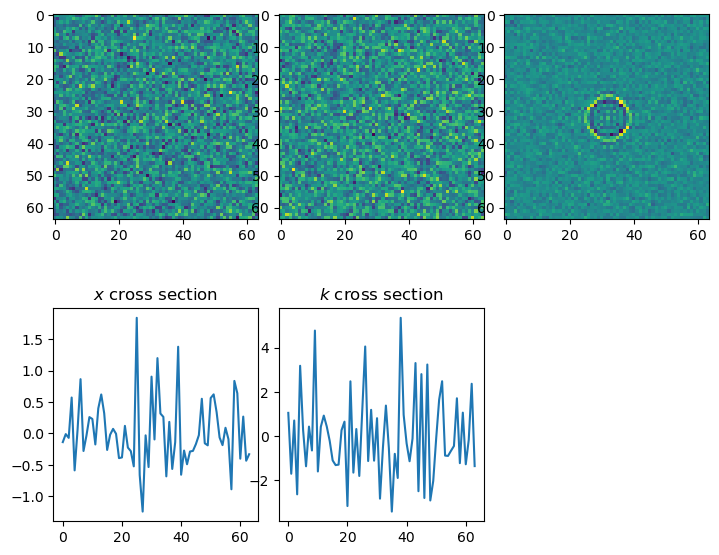

In [2]:
# Setup the initial real space field
npnts = (64, 64)
scale = 0.1
ct = 40
field = 1 .+ scale .* Random.randn(ComplexF64, npnts)
# field[32,32] += 1


# transform to k-space
field_fft  = FFTW.fft(field)

# get kx and ky values
kx = FFTW.fftfreq(npnts[1])
ky = FFTW.fftfreq(npnts[2])

# Transform forward in time

for i in 1:npnts[1], j in 1:npnts[2]
    field_fft[i,j] *= exp(complex(0, ct * sqrt(kx[i]^2 + ky[j]^2) ))
end
field_final = FFTW.ifft(field_fft)

# Get intensities
intensity = abs.(field)
intensity .-= Stat.mean(intensity)

intensity_final = abs.(field_final)
intensity_final .-= Stat.mean(intensity_final)


# get CCF
int_fft = FFTW.fft(intensity)
int_final_fft = FFTW.fft(intensity_final)

cpsd = int_fft .* conj(int_final_fft)
cpsd_sect = cpsd[:,1]

ccf = FFTW.ifft(cpsd)
ccf_x_cut = FFTW.fftshift(ccf[:,1])
ccf = FFTW.fftshift(ccf)
ccf_k_cut = FFTW.fftshift(FFTW.ifft(cpsd_sect))


# Plot it up
fig = plt.figure(figsize=Tuple([8,10]))
gs = fig.add_gridspec(3, 3)
gs.update(left=0.15, bottom=0.12, top=0.93, wspace=0.1, hspace=0.4, right=0.97) 

ax = fig.add_subplot(gs[1,1])
ax.imshow(intensity)

ax = fig.add_subplot(gs[1,2])
ax.imshow(intensity_final)

ax = fig.add_subplot(gs[1,3])
ax.imshow(real(ccf))

ax = fig.add_subplot(gs[2,1])
ax.plot(ccf_x_cut)
ax.set_title(L"$x$ cross section")

ax = fig.add_subplot(gs[2,2])
ax.plot(real(ccf_k_cut))
ax.set_title(L"$k$ cross section")



plt.gcf()

Next I am going to update this to do averaging.  First lets try making wider cuts

/Users/ispielma/.julia/conda/3/aarch64/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ispielma/.julia/conda/3/aarch64/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


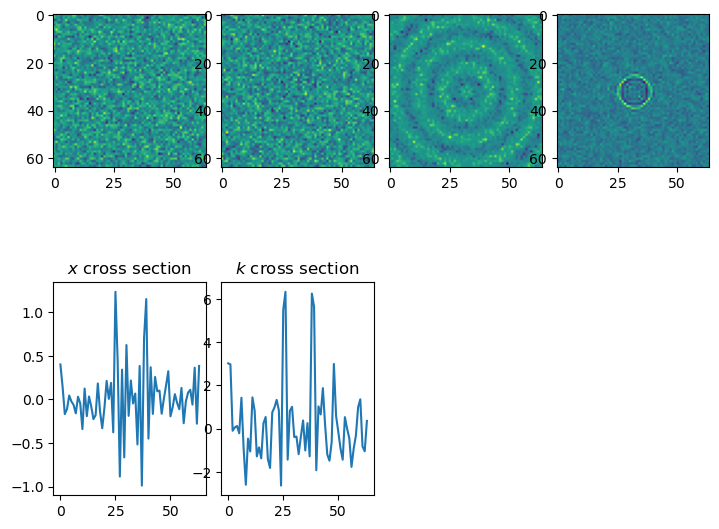

In [6]:
# Setup the initial real space field
npnts = (64, 64)
scale = 0.1
ct = 40

width = 1
field = 1 .+ scale .* Random.randn(ComplexF64, npnts)
# field[32,32] += 1


# transform to k-space
field_fft  = FFTW.fft(field)

# get kx and ky values
kx = FFTW.fftfreq(npnts[1])
ky = FFTW.fftfreq(npnts[2])

# Transform forward in time

for i in 1:npnts[1], j in 1:npnts[2]
    field_fft[i,j] *= exp(complex(0, ct * sqrt(kx[i]^2 + ky[j]^2) ))
end
field_final = FFTW.ifft(field_fft)

# Get intensities
intensity = abs.(field)
intensity .-= Stat.mean(intensity)

intensity_final = abs.(field_final)
intensity_final .-= Stat.mean(intensity_final)


# get CCF
int_fft = FFTW.fft(intensity)
int_final_fft = FFTW.fft(intensity_final)

cpsd = int_fft .* conj(int_final_fft)
cpsd_sect = cpsd[:,vcat(1:width, (end-width):end)] # because we are looking at the top and bottom edges
cpsd_sect = Stat.mean(cpsd_sect, dims=2)

ccf = FFTW.ifft(cpsd)
ccf_x_cut = ccf[:,vcat(1:width, (end-width):end)] # because we are looking at the top and bottom edges
ccf_x_cut = Stat.mean(ccf_x_cut, dims=2)
ccf_x_cut = FFTW.fftshift(ccf_x_cut)

ccf = FFTW.fftshift(ccf)
ccf_k_cut = FFTW.fftshift(FFTW.ifft(cpsd_sect))


# Plot it up
fig = plt.figure(figsize=Tuple([8,10]))
gs = fig.add_gridspec(3, 4)
gs.update(left=0.15, bottom=0.12, top=0.93, wspace=0.1, hspace=0.4, right=0.97) 

ax = fig.add_subplot(gs[1,1])
ax.imshow(intensity)

ax = fig.add_subplot(gs[1,2])
ax.imshow(intensity_final)

ax = fig.add_subplot(gs[1,3])
ax.imshow(real(FFTW.fftshift(cpsd)))

ax = fig.add_subplot(gs[1,4])
ax.imshow(real(ccf))

ax = fig.add_subplot(gs[2,1])
ax.plot(ccf_x_cut)
ax.set_title(L"$x$ cross section")

ax = fig.add_subplot(gs[2,2])
ax.plot(real(ccf_k_cut))
ax.set_title(L"$k$ cross section")



plt.gcf()

# Averaging over runs

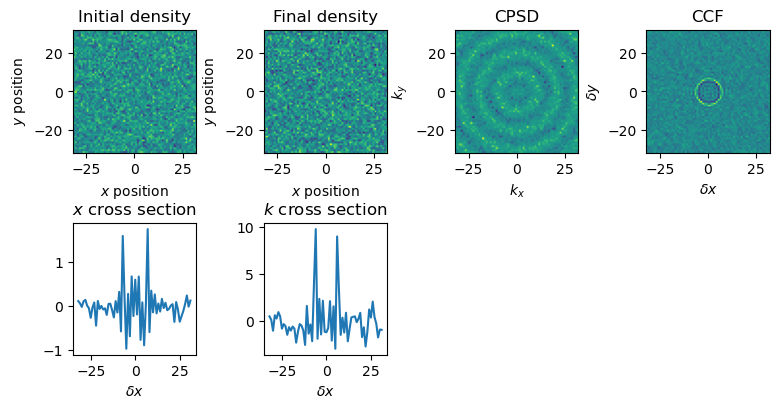

In [7]:
# Setup the initial real space field
npnts = (64, 64)
scale = 0.1
ct = 40
loops = 8

# get kx and ky values
kx = FFTW.fftfreq(npnts[1])
ky = FFTW.fftfreq(npnts[2])
x_vals = FFTW.fftshift(FFTW.fftfreq(npnts[1], npnts[1]))

local ccf_x_cut = zeros(Float64, npnts[1])
local ccf_k_cut = zeros(Float64, npnts[1])

for j in 1:loops
    field = 1 .+ scale .* Random.randn(ComplexF64, npnts)

    # transform to k-space
    field_fft = FFTW.fft(field)

    # Transform forward in time

    for i in 1:npnts[1], j in 1:npnts[2]
        field_fft[i,j] *= exp(complex(0, ct * sqrt(kx[i]^2 + ky[j]^2) ))
    end
    field_final = FFTW.ifft(field_fft)

    # Get intensities
    intensity = abs.(field)
    intensity .-= Stat.mean(intensity)

    intensity_final = abs.(field_final)
    intensity_final .-= Stat.mean(intensity_final)


    # get CCF
    int_fft = FFTW.fft(intensity)
    int_final_fft = FFTW.fft(intensity_final)

    cpsd = int_fft .* conj(int_final_fft)
    cpsd_sect = cpsd[:,1]

    ccf = FFTW.ifft(cpsd)
    ccf_x_cut .+= FFTW.fftshift(ccf[:,1])
    
    ccf = FFTW.fftshift(ccf)
    ccf_k_cut .+= FFTW.fftshift(FFTW.ifft(cpsd_sect))
end

ccf_x_cut ./= loops
ccf_k_cut ./= loops

# Plot it up
fig = plt.figure(figsize=Tuple([8.5,6.5]))
gs = fig.add_gridspec(3, 4)
gs.update(left=0.15, bottom=0.12, top=0.93, wspace=0.55, hspace=0.5, right=0.97) 

ax = fig.add_subplot(gs[1,1])
ax.imshow(intensity, extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("Initial density")
ax.set_xlabel(L"$x$ position")
ax.set_ylabel(L"$y$ position")

ax = fig.add_subplot(gs[1,2])
ax.imshow(intensity_final, extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("Final density")
ax.set_xlabel(L"$x$ position")
ax.set_ylabel(L"$y$ position")

ax = fig.add_subplot(gs[1,3])
ax.imshow(real(FFTW.fftshift(cpsd)), extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("CPSD")
ax.set_xlabel(L"$k_x$")
ax.set_ylabel(L"$k_y$")

ax = fig.add_subplot(gs[1,4])
ax.imshow(real(ccf), extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("CCF")
ax.set_xlabel(L"$\delta x$")
ax.set_ylabel(L"$\delta y$")

ax = fig.add_subplot(gs[2,1])
ax.plot(x_vals, ccf_x_cut)
ax.set_title(L"$x$ cross section")
ax.set_xlabel(L"$\delta x$")

ax = fig.add_subplot(gs[2,2])
ax.plot(x_vals, ccf_k_cut)
ax.set_title(L"$k$ cross section")
ax.set_xlabel(L"$\delta x$")



plt.gcf()

# Averaging over runs and finite-width strips

In [4]:
# AVERAGING AND WIDTH 

# Setup the initial real space field
npnts = (64, 64)
scale = 0.1
ct = 40
loops = 8
width = 2 # strip width is 2*width + 1


# get kx and ky values
kx = FFTW.fftfreq(npnts[1])
ky = FFTW.fftfreq(npnts[2])
x_vals = FFTW.fftshift(FFTW.fftfreq(npnts[1], npnts[1]))

local ccf_x_cut = zeros(Float64, npnts[1])
local ccf_k_cut = zeros(Float64, npnts[1])

for j in 1:loops
    field = 1 .+ scale .* Random.randn(ComplexF64, npnts)

    # transform to k-space
    field_fft = FFTW.fft(field)

    # Transform forward in time

    for i in 1:npnts[1], j in 1:npnts[2]
        field_fft[i,j] *= exp(complex(0, ct * sqrt(kx[i]^2 + ky[j]^2) ))
    end
    field_final = FFTW.ifft(field_fft)

    # Get intensities
    intensity = abs.(field)
    intensity .-= Stat.mean(intensity)

    intensity_final = abs.(field_final)
    intensity_final .-= Stat.mean(intensity_final)


    # get CCF
    int_fft = FFTW.fft(intensity)
    int_final_fft = FFTW.fft(intensity_final)

    cpsd = int_fft .* conj(int_final_fft)
    cpsd_sect = cpsd[:,vcat(1:width, (end-width):end)] # because we are looking at the top and bottom edges
    cpsd_sect = Stat.mean(cpsd_sect, dims=2)
    
    ccf = FFTW.ifft(cpsd)
    ccf_x_cut = ccf[:,vcat(1:width, (end-width):end)] # because we are looking at the top and bottom edges
    ccf_x_cut = Stat.mean(ccf_x_cut, dims=2)
    ccf_x_cut = FFTW.fftshift(ccf_x_cut)
        
    ccf = FFTW.fftshift(ccf)
    ccf_k_cut .+= FFTW.fftshift(FFTW.ifft(cpsd_sect))
end

ccf_x_cut ./= loops
ccf_k_cut ./= loops

# Plot it up
fig = plt.figure(figsize=Tuple([8.5,6.5]))
gs = fig.add_gridspec(3, 4)
gs.update(left=0.15, bottom=0.12, top=0.93, wspace=0.55, hspace=0.5, right=0.97) 

ax = fig.add_subplot(gs[1,1])
ax.imshow(intensity, extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("Initial density")
ax.set_xlabel(L"$x$ position")
ax.set_ylabel(L"$y$ position")

ax = fig.add_subplot(gs[1,2])
ax.imshow(intensity_final, extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("Final density")
ax.set_xlabel(L"$x$ position")
ax.set_ylabel(L"$y$ position")

ax = fig.add_subplot(gs[1,3])
ax.imshow(real(FFTW.fftshift(cpsd)), extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("CPSD")
ax.set_xlabel(L"$k_x$")
ax.set_ylabel(L"$k_y$")

ax = fig.add_subplot(gs[1,4])
ax.imshow(real(ccf), extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
ax.set_title("CCF")
ax.set_xlabel(L"$\delta x$")
ax.set_ylabel(L"$\delta y$")

ax = fig.add_subplot(gs[2,1])
ax.plot(x_vals, ccf_x_cut)
ax.set_title(L"$x$ cross section")
ax.set_xlabel(L"$\delta x$")

ax = fig.add_subplot(gs[2,2])
ax.plot(x_vals, ccf_k_cut)
ax.set_title(L"$k$ cross section")
ax.set_xlabel(L"$\delta x$")



plt.gcf()

UndefVarError: UndefVarError: `ccf_k_cut` not defined

# Phonon-like dispersion

In [59]:
"""
I am picking units where c = 1 so ct is really just time
"""
function dispersion(kx, ky, ct, k_cross)
    κ = sqrt.(kx.^2 .+ ky.^2)
    ϵ = ct .* κ .* sqrt.(1 .+ κ ./ k_cross)
    return ϵ
end

function plot_bdg(x_vals, npnts, kx, ky,  ct, k_cross, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut)
    # Plot it up
    fig = plt.figure(figsize=Tuple([8.5,6.5]))
    gs = fig.add_gridspec(3, 4)
    gs.update(left=0.15, bottom=0.12, top=0.93, wspace=0.55, hspace=0.5, right=0.97) 

    ax = fig.add_subplot(gs[1,1])
    ax.imshow(intensity, extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
    ax.set_title("Initial density")
    ax.set_xlabel(L"$x$ position")
    ax.set_ylabel(L"$y$ position")

    ax = fig.add_subplot(gs[1,2])
    ax.imshow(intensity_final, extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
    ax.set_title("Final density")
    ax.set_xlabel(L"$x$ position")
    ax.set_ylabel(L"$y$ position")

    ax = fig.add_subplot(gs[1,3])
    ax.imshow(real(FFTW.fftshift(cpsd)), extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
    ax.set_title("CPSD")
    ax.set_xlabel(L"$k_x$")
    ax.set_ylabel(L"$k_y$")

    ax = fig.add_subplot(gs[1,4])
    ax.imshow(real(ccf), extent=(-npnts[1]/2, npnts[1]/2, -npnts[2]/2, npnts[2]/2) )
    ax.set_title("CCF")
    ax.set_xlabel(L"$\delta x$")
    ax.set_ylabel(L"$\delta y$")

    ax = fig.add_subplot(gs[2,1])
    ax.plot(x_vals, ccf_x_cut)
    ax.set_title(L"$x$ cross section")
    ax.set_xlabel(L"$\delta x$")

    ax = fig.add_subplot(gs[2,2])
    ax.plot(x_vals, ccf_k_cut)
    ax.set_title(L"$k$ cross section")
    ax.set_xlabel(L"$\delta x$")

    ax = fig.add_subplot(gs[2,3])
    ax.plot(kx, dispersion(kx, 0, ct, k_cross), ",")
    ax.plot(kx, dispersion(kx, 0, ct, 100), ",")
    ax.set_title(L"Disperseion")
    ax.set_xlabel(L"$k_xx$")

    plt.gcf()
end

function run_sim(npnts, scale, ct, k_cross)

    # get kx and ky values
    kx_loc = FFTW.fftfreq(npnts[1])
    ky_loc = FFTW.fftfreq(npnts[2])
    x_vals_loc = FFTW.fftshift(FFTW.fftfreq(npnts[1], npnts[1]))

    ccf_x_cut_loc = zeros(Float64, npnts[1])
    ccf_k_cut_loc = zeros(Float64, npnts[1])

    local intensity_loc = zeros(Float64, npnts[1], npnts[2])
    local intensity_final_loc = zeros(Float64, npnts[1], npnts[2])
    local cpsd_loc = zeros(Float64, npnts[1])
    local ccf_loc = zeros(Float64, npnts[1])

    for j in 1:loops
        field = 1 .+ scale .* Random.randn(ComplexF64, npnts)

        # transform to k-space
        field_fft = FFTW.fft(field)

        # Transform forward in time

        for i in 1:npnts[1], j in 1:npnts[2]
            field_fft[i,j] *= exp(complex(0, dispersion(kx_loc[i], ky_loc[j], ct, k_cross) ))
        end
        field_final = FFTW.ifft(field_fft)

        # Get intensities
        intensity_loc = abs.(field)
        intensity_loc .-= Stat.mean(intensity_loc)

        intensity_final_loc = abs.(field_final)
        intensity_final_loc .-= Stat.mean(intensity_final_loc)


        # get CCF
        int_fft = FFTW.fft(intensity_loc)
        int_final_fft = FFTW.fft(intensity_final_loc)

        cpsd_loc = int_fft .* conj(int_final_fft)
        cpsd_sect_loc = cpsd_loc[:,1]

        ccf_loc = real(FFTW.ifft(cpsd_loc))
        ccf_x_cut_loc .+= FFTW.fftshift(ccf_loc[:,1])
        
        ccf_loc = FFTW.fftshift(ccf_loc)
        ccf_k_cut_loc .+= real(FFTW.fftshift(FFTW.ifft(cpsd_sect_loc)))
    end

    ccf_x_cut_loc ./= loops
    ccf_k_cut_loc ./= loops

    return (kx_loc, ky_loc, x_vals_loc, intensity_loc, intensity_final_loc, cpsd_loc, ccf_loc, ccf_x_cut_loc, ccf_k_cut_loc)
end

run_sim (generic function with 1 method)

For comparisonI will first plot up the case for linear dispersion

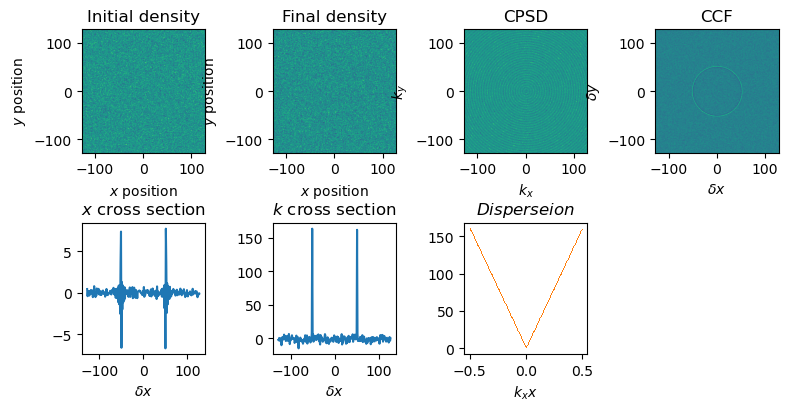

In [60]:
# Setup the initial real space field
npnts = (256, 256)
scale = 0.1
ct = 320
k_cross = 100
loops = 32

(kx, ky, x_vals, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut) = run_sim(npnts, scale, ct, k_cross)

# Plot it up
plot_bdg(x_vals, npnts, kx, ky,  ct, k_cross, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut)

Next I will do the case with a BDG dispersion

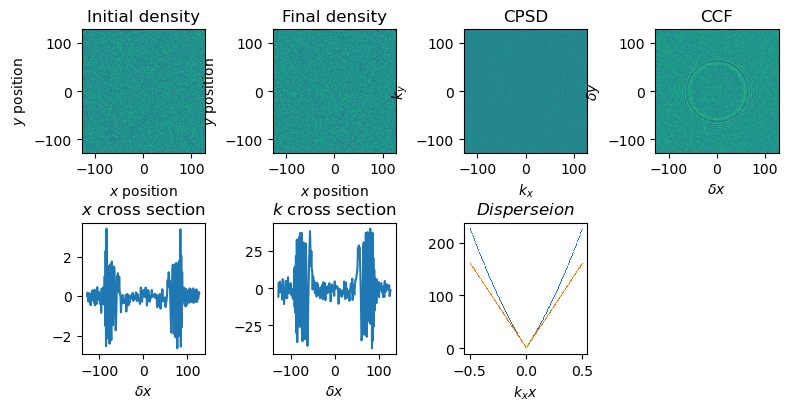

In [61]:
# Setup the initial real space field
npnts = (256, 256)
scale = 0.1
ct = 320
k_cross = 0.5
loops = 32

(kx, ky, x_vals, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut) = run_sim(npnts, scale, ct, k_cross)

# Plot it up
plot_bdg(x_vals, npnts, kx, ky,  ct, k_cross, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut)

How do these compare at short time?  What about if there is a physics based low pass filter?

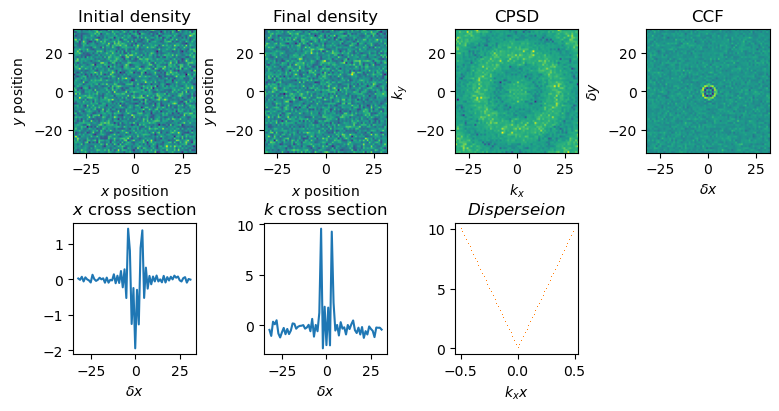

In [73]:
# Setup the initial real space field
npnts = (64, 64)
scale = 0.1
ct = 20
k_cross = 100
loops = 32

(kx, ky, x_vals, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut) = run_sim(npnts, scale, ct, k_cross)

# Plot it up
plot_bdg(x_vals, npnts, kx, ky,  ct, k_cross, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut)

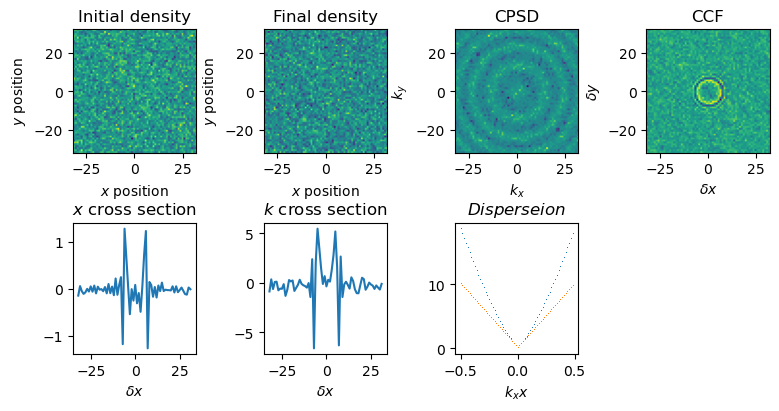

In [90]:
# Setup the initial real space field
npnts = (64, 64)
scale = 0.1
ct = 20
k_cross = 0.2
loops = 32

(kx, ky, x_vals, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut) = run_sim(npnts, scale, ct, k_cross)

# Plot it up
plot_bdg(x_vals, npnts, kx, ky,  ct, k_cross, intensity, intensity_final, cpsd, ccf, ccf_x_cut, ccf_k_cut)